In [ ]:
import pandas as pd
import numpy as np


In [10]:
df = pd.read_csv("Churn_Modelling.csv")
df.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [14]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [15]:
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [24]:
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True, dtype=int)

In [25]:
X= df.drop('Exited', axis=1)
y= df['Exited']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [26]:
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,0,1


In [27]:
y

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64

In [28]:
X_train.shape

(8000, 11)

In [30]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
X_train_scaled

array([[-0.23082038, -0.94449979, -0.70174202, ...,  1.71490137,
        -0.57273139,  0.91509065],
       [-0.25150912, -0.94449979, -0.35520275, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [-0.3963303 ,  0.77498705,  0.33787579, ...,  1.71490137,
        -0.57273139, -1.09278791],
       ...,
       [ 0.22433188,  0.58393295,  1.3774936 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 0.13123255,  0.01077067,  1.03095433, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 1.1656695 ,  0.29735181,  0.33787579, ...,  1.71490137,
        -0.57273139,  0.91509065]], shape=(8000, 11))

In [32]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [85]:
model = Sequential()
model.add(Dense(11, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dense(11, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dense(1, activation='relu'))

d:\Deep Learning\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [86]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [87]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [88]:
history = model.fit(X_train_scaled, y_train, epochs=10,batch_size=32,validation_data=(X_test_scaled, y_test))

Epoch 1/10


250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7747 - loss: 0.7680 - val_accuracy: 0.8040 - val_loss: 0.5461
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8029 - loss: 0.5234 - val_accuracy: 0.8140 - val_loss: 0.4861
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8117 - loss: 0.4909 - val_accuracy: 0.8200 - val_loss: 0.4581
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8149 - loss: 0.4688 - val_accuracy: 0.8245 - val_loss: 0.4631
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8195 - loss: 0.4556 - val_accuracy: 0.8280 - val_loss: 0.4503
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8214 - loss: 0.4493 - val_accuracy: 0.8310 - val_loss: 0.4519
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8231 - loss: 0.4499 - val_accuracy: 0.8335 - val_loss: 0.4379
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8288 - loss: 0.4295 - val_accuracy: 0.8375 - val_

In [89]:
model.layers[0].get_weights()

[array([[ 0.03877021, -0.37591156, -0.17237347,  0.22763757,  0.1522458 ,
         -0.22266805, -0.00450334,  0.18527144,  0.06169922, -0.35585493,
         -0.32714713],
        [ 0.44761944,  0.45353296,  0.2943445 , -0.25685707, -0.3733176 ,
          0.1292518 , -0.5387031 , -0.47804102,  0.17188998,  0.17797852,
         -0.43186563],
        [ 0.09576748,  0.38173643, -0.05635519, -0.15557912, -0.08101042,
          0.28357908, -0.33876348, -0.05630947,  0.20690463,  0.4174568 ,
         -0.36840373],
        [-0.07293197,  0.2551724 ,  0.3372167 , -0.2576881 ,  0.2620899 ,
         -0.09236315, -0.3545814 ,  0.41479823,  0.51418483, -0.1488733 ,
         -0.08710273],
        [-0.59550667, -0.44655573,  0.43939784,  0.26202112,  0.41157582,
          0.24556603,  0.17736714,  0.14120267,  0.08856102, -0.17448944,
         -0.16027184],
        [ 0.13776134,  0.01401921, -0.02818338, -0.472646  ,  0.38876048,
          0.44331694,  0.12969017, -0.1843361 , -0.07527081, -0.1234885

In [90]:
model.layers[1].get_weights()

[array([[ 0.351846  , -0.452584  , -0.27879465,  0.64184433,  0.21543552,
          0.3733438 ,  0.17407224, -0.16048352,  0.11610853,  0.00938123,
          0.51481676],
        [-0.07705693,  0.44576573, -0.1678448 ,  0.21557105,  0.25606915,
         -0.38395062, -0.01754603,  0.10762045, -0.45890468, -0.3203641 ,
         -0.16150545],
        [-0.03295138, -0.03236973,  0.07588939, -0.07743249,  0.03571469,
         -0.31642497, -0.11064295,  0.26020348,  0.20326258,  0.38613394,
          0.4581764 ],
        [ 0.2145646 ,  0.0124146 ,  0.37450927, -0.0926414 ,  0.25847018,
          0.12681082,  0.3330476 ,  0.14049508, -0.3127048 , -0.37529746,
          0.31660116],
        [-0.25205386, -0.36197823, -0.21105944, -0.36904347, -0.38103366,
         -0.51211905, -0.34138638, -0.262192  ,  0.36091617, -0.30558872,
         -0.28958017],
        [-0.47314376, -0.30298018,  0.02760065, -0.4895582 ,  0.12463798,
         -0.5857611 , -0.3755732 ,  0.16424417,  0.09294848, -0.4600364

In [91]:
y_log = model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


In [92]:
y_pred = np.where(y_log > 0.5, 1, 0)

In [93]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print(accuracy_score(y_test, y_pred))

0.8385


In [94]:
import matplotlib.pyplot as plt

In [95]:
history.history

{'accuracy': [0.7747499942779541,
  0.8028749823570251,
  0.8117499947547913,
  0.8148750066757202,
  0.8195000290870667,
  0.8213750123977661,
  0.8231250047683716,
  0.8287500143051147,
  0.8309999704360962,
  0.8343750238418579],
 'loss': [0.7679789662361145,
  0.5234268307685852,
  0.49090641736984253,
  0.46875569224357605,
  0.45555856823921204,
  0.4493495523929596,
  0.4499206840991974,
  0.429543673992157,
  0.4218311011791229,
  0.41497519612312317],
 'val_accuracy': [0.8040000200271606,
  0.8140000104904175,
  0.8199999928474426,
  0.8245000243186951,
  0.828000009059906,
  0.8309999704360962,
  0.8335000276565552,
  0.8374999761581421,
  0.8379999995231628,
  0.8385000228881836],
 'val_loss': [0.5460827350616455,
  0.4861304461956024,
  0.458127498626709,
  0.4630546569824219,
  0.4503442347049713,
  0.4519089460372925,
  0.43792209029197693,
  0.4342329204082489,
  0.43516457080841064,
  0.4259474575519562]}

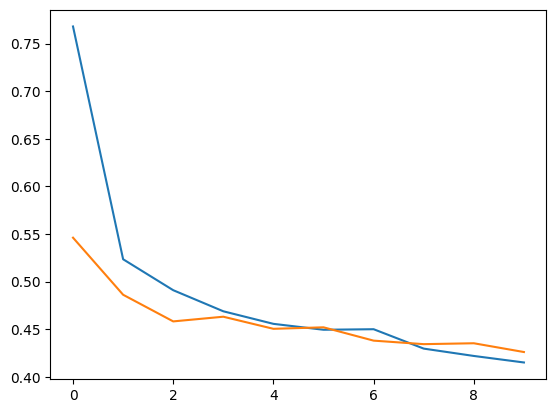

In [96]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')